In [ ]:
from google.colab import files
uploaded = files.upload()

Saving E-commerce.csv.xlsx to E-commerce.csv.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("E-commerce.csv.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df = df.dropna(subset=["CustomerID"])

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df = df[df["Quantity"] > 0]

In [ ]:
df = df[df["UnitPrice"] > 0]

In [ ]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [ ]:
latest_date = df["InvoiceDate"].max()
latest_date

Timestamp('2011-12-10 17:19:00')

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalAmount": "sum"
})

In [ ]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,40,182,4310.00
12348.0,76,31,1797.24
12349.0,19,73,1757.55
12350.0,311,17,334.40


In [ ]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [ ]:
rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,40,182,4310.00,4,5,5,455
12348.0,76,31,1797.24,3,3,4,334
12349.0,19,73,1757.55,4,4,4,444
12350.0,311,17,334.40,1,2,2,122


In [ ]:
rfm.shape

(4338, 7)

In [ ]:
def segment_customer(row):
    if row["RFM_Score"] == "555":
        return "Champions"
    elif row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Loyal Customers"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Potential Loyalists"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    else:
        return "Lost Customers"

In [ ]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm["Segment"].value_counts()

,count
Segment,
Lost Customers,1735
Loyal Customers,1080
Potential Loyalists,731
At Risk,504
Champions,288


<Axes: xlabel='Segment'>

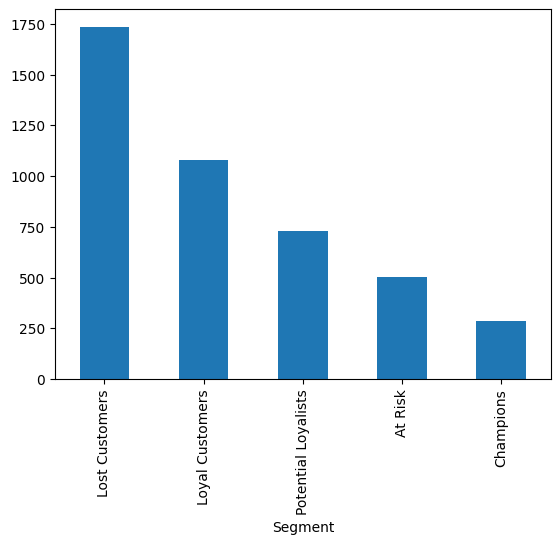

In [ ]:
rfm["Segment"].value_counts().plot(kind="bar")

In [ ]:
df.to_csv('cleaned_E-commerce.csv', index=False)

In [ ]:
print(rfm)

            Recency  Frequency  Monetary R_score F_score M_score RFM_Score  \
CustomerID                                                                   
12346.0         326          1  77183.60       1       1       5       115   
12347.0          40        182   4310.00       4       5       5       455   
12348.0          76         31   1797.24       3       3       4       334   
12349.0          19         73   1757.55       4       4       4       444   
12350.0         311         17    334.40       1       2       2       122   
...             ...        ...       ...     ...     ...     ...       ...   
18280.0         160         10    180.60       2       1       1       211   
18281.0           4          7     80.82       5       1       1       511   
18282.0         216         12    178.05       1       1       1       111   
18283.0          10        756   2094.88       5       5       5       555   
18287.0           0         70   1837.28       5       4       4

In [ ]:
rfm = rfm.reset_index()

In [ ]:
rfm.to_csv("rfm_table.csv", index=False)

In [ ]:
from google.colab import files
files.download("rfm_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>